SPIM Excitation Lightpath Design with ABCD Matrix
=================================================

Using on [RayTraicing lib](https://raytracing.readthedocs.io/en/master/index.html)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from raytracing import *

## Total lightpath design

### XY plane

In [63]:
f_cyl = 75
f_scan = 50
f_tube = 30
f_obj = 45

# Simple lens definition
# Lens_cyl = Lens(f=f_cyl, diameter=25.4, label="Cyl.")
# Lens_scan = Lens(f=f_scan, diameter=25.4, label="Scan")
# Lens_tube = Lens(f=f_tube, diameter=25.4, label="Tube")
# Lens_obj = Lens(f=f_obj, diameter=9, label="Obj. 4X")

# Complex definition
Lens_cyl = thorlabs.LA1608_A(wavelength=0.5)
Lens_scan = thorlabs.AC254_050_A(wavelength=0.5)
Lens_tube = thorlabs.AC254_030_A(wavelength=0.5)
Lens_obj = thorlabs.AC254_045_A(wavelength=0.5)
# Lens_obj = Objective(f=f_obj, NA=0.1, fieldNumber=22, magnification=4, workingDistance=18.5,
#                      backAperture=9, focusToFocusLength=90, label="Obj. 4X")

ExpertNote [in specialtylenses.py]: Singlet LA1608_A: Obtained effective focal length 74.03 is not within 1% of expected 72.0
ExpertNote [in specialtylenses.py]: Doublet AC254-030-A: Obtained back focal length 22.15 is not within 1% of expected 22.9


In [64]:
x_path = LaserPath()
x_path.append(Space(d=20))
x_path.append(Lens_cyl)
x_path.append(Space(d=Lens_cyl.backFocalLength()+f_scan))
x_path.append(Lens_scan)
x_path.append(Space(d=Lens_scan.backFocalLength()+f_tube))
x_path.append(Lens_tube)
x_path.append(Space(d=Lens_tube.backFocalLength()+f_obj))
x_path.append(Lens_obj)
x_path.append(Space(d=100))

In [74]:
x_path.principalPlanePositions(0)

PrincipalPlanes(z1=1.8892157701925043, z2=415.46280335843664)

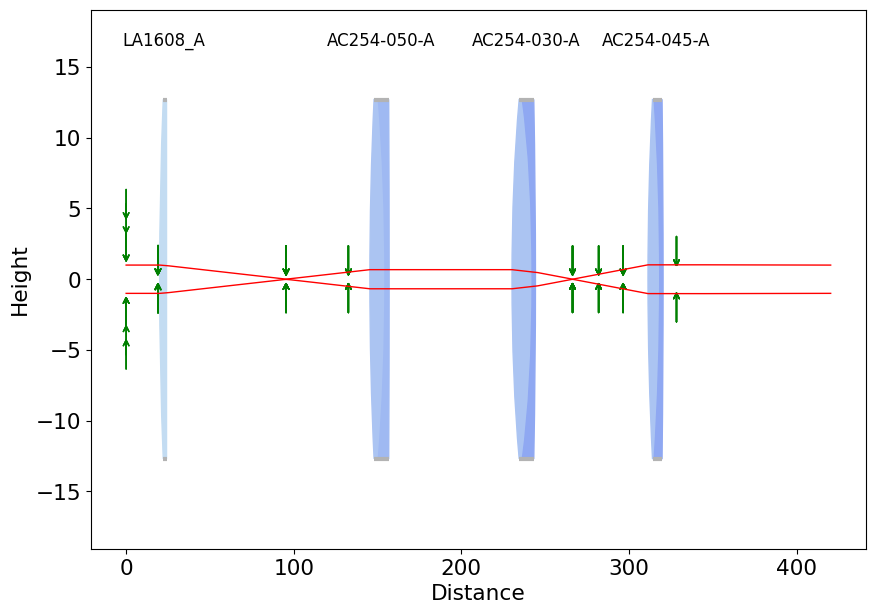

In [75]:
x_path.display(beams=[GaussianBeam(w=1)])